### Imports

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


### Data

In [8]:
series_1 = {
    "run_1": {
        "static_pressure": [370, 350, 110, 220, 240, 260],   # mm Hg
        "total_pressure":  [410, 400, 390, 280, 280, 290],   # mm Hg
        "Q": 10,                                             # l
        "t": 68                                              # s
    },
    "run_2": {
        "static_pressure": [390, 360, 10, 160, 200, 230],    # mm Hg
        "total_pressure":  [430, 410, 390, 260, 260, 270],   # mm Hg
        "Q": 10,                                             # l
        "t": 42                                              # s
    },
    "run_3": {
        "static_pressure": [330, 310, 70, 170, 190, 200],   # mm Hg
        "total_pressure":  [340, 340, 330, 230, 230, 230],  # mm Hg
        "Q": 10,                                            # l
        "t": 57                                             # s
    },
    "run_4": {
        "static_pressure": [310, 300, 140, 210, 240, 250],  # mm Hg
        "total_pressure":  [350, 350, 340, 280, 270, 280],  # mm Hg
        "Q": 10,                                            # l
        "t": 64                                             # s 
    },
    "run_5": {
        "static_pressure": [230, 220, 130, 170, 180, 180],  # mm Hg
        "total_pressure":  [240, 240, 230, 200, 200, 200],  # mm Hg
        "Q": 10,                                            # l
        "t": 88                                             # s
    },
    "run_6": {
        "static_pressure": [310, 290, 40, 145, 180, 195],
        "total_pressure":  [350, 350, 345, 230, 235, 240],
        "Q": 10,
        "t": 69
    },
    "run_7": {
        "static_pressure": [340, 325, 75, 185, 220, 235],
        "total_pressure":  [390, 385, 375, 265, 270, 275],
        "Q": 10,
        "t": 60
    },
    "run_8": {
        "static_pressure": [310, 300, 115, 195, 215, 230],
        "total_pressure":  [345, 345, 335, 240, 250, 260],
        "Q": 10,
        "t": 60
    },
    "run_9": {
        "static_pressure": [320, 310, 190, 240, 255, 260],
        "total_pressure":  [335, 335, 330, 270, 270, 280],
        "Q": 10,
        "t": 60
    },
    "run_10": {
        "static_pressure": [250, 245, 145, 185, 200, 205],
        "total_pressure":  [250, 270, 265, 215, 215, 220],
        "Q": 10,
        "t": 68
    },

    "run_11": {
        "static_pressure": [270, 260, 170, 210, 220, 230],
        "total_pressure":  [280, 270, 260, 230, 240, 240],
        "Q": 10,
        "t": 61
    },
    "run_12": {
        "static_pressure": [340, 330, 120, 210, 240, 250],
        "total_pressure":  [350, 350, 330, 260, 270, 280],
        "Q": 10,
        "t": 63
    },
    "run_13": {
        "static_pressure": [290, 290, 260, 270, 270, 270],
        "total_pressure":  [300, 290, 290, 280, 280, 280],
        "Q": 10,
        "t": 62
    },
    "run_14": {
        "static_pressure": [280, 270, 170, 220, 230, 240],
        "total_pressure":  [275, 275, 270, 235, 235, 240],
        "Q": 10,
        "t": 63
    },
    "run_15": {
        "static_pressure": [270, 255, 5, 115, 145, 160],
        "total_pressure":  [310, 305, 285, 185, 190, 200],
        "Q": 10,
        "t": 67
    }
}

In [ ]:
series = {
    # Page 1 – digital spreadsheet (3 series + rotameter table)
    "run_1": {
        "static_pressure": [395, 360, 75, 185, 210, 225],   # mm Hg
        "total_pressure":  [470, 400, 400, 315, 265, 295],   # mm Hg
        "Q": 10,                                             # l
        "t": 52.71                                              # s
    },
    "run_2": {
        "static_pressure": [375, 360, 65, 180, 210, 295],   # mm Hg
        "total_pressure":  [390, 400, 405, 320, 260, 340],   # mm Hg
        "Q": 10,                                             # l
        "t": 51.25                                              # s
    },
    "run_3": {
        "static_pressure": [325, 310, 65, 155, 180, 145],   # mm Hg
        "total_pressure":  [340, 345, 345, 270, 230, 235],   # mm Hg
        "Q": 10,                                             # l
        "t": 57.9                                              # s
    },
    # Page 2 – Karta pomiarowa, Zespol 3, 06.11.2025
    "run_4": {
        "static_pressure": [335, 315, 85, 185, 225, 230],   # mm Hg
        "total_pressure":  [375, 370, 370, 265, 260, 265],   # mm Hg
        "Q": 10,                                             # l
        "t": 55                                              # s
    },
    "run_5": {
        "static_pressure": [155, 150, 15, 75, 30, 35],   # mm Hg
        "total_pressure":  [180, 190, 180, 125, 125, 125],   # mm Hg
        "Q": 10,                                             # l
        "t": 74.5                                              # s
    },
    "run_6": {
        "static_pressure": [335, 330, 250, 285, 295, 305],   # mm Hg
        "total_pressure":  [345, 345, 350, 310, 310, 310],   # mm Hg
        "Q": 10,                                             # l
        "t": 100                                              # s
    },
    # Page 3 – handwritten notes
    "run_7": {
        "static_pressure": [310, 295, 105, 185, 210, 220],   # mm Hg
        "total_pressure":  [340, 340, 340, 230, 240, 250],   # mm Hg
        "Q": 10,                                             # l
        "t": 60.31                                              # s
    },
    "run_8": {
        "static_pressure": [380, 325, 45, 170, 200, 220],   # mm Hg
        "total_pressure":  [390, 395, 390, 235, 245, 260],   # mm Hg
        "Q": 10,                                             # l
        "t": 45.35                                              # s
    },
    "run_9": {
        "static_pressure": [340, 340, 35, 160, 200, 220],   # mm Hg
        "total_pressure":  [400, 400, 400, 260, 260, 270],   # mm Hg
        "Q": 10,                                             # l
        "t": 48.47                                              # s
    },
    # Page 4 – handwritten notes (2 series)
    "run_10": {
        "static_pressure": [340, 325, 260, 235, 255, 265],   # mm Hg
        "total_pressure":  [365, 365, 365, 290, 280, 285],   # mm Hg
        "Q": 10,                                             # l
        "t": 67.03                                              # s
    },
    "run_11": {
        "static_pressure": [320, 300, 35, 155, 185, 205],   # mm Hg
        "total_pressure":  [370, 365, 365, 225, 230, 245],   # mm Hg
        "Q": 10,                                             # l
        "t": 49.22                                              # s
    },
    # Page 5 – Karta pomiarowa, Zespol 2, 30.10.2025
    "run_12": {
        "static_pressure": [320, 310, 185, 240, 55, 265],   # mm Hg
        "total_pressure":  [345, 347, 340, 275, 275, 275],   # mm Hg
        "Q": 10,                                             # l
        "t": 77.135                                              # s
    },
    "run_13": {
        "static_pressure": [310, 285, 25, 140, 175, 180],   # mm Hg
        "total_pressure":  [353, 350, 350, 250, 220, 230],   # mm Hg
        "Q": 10,                                             # l
        "t": 51.295                                              # s
    },
    # Page 6 – digital spreadsheet, Group A
    "run_14": {
        "static_pressure": [235, 225, 100, 155, 170, 175],   # mm Hg
        "total_pressure":  [260, 260, 270, 215, 215, 220],   # mm Hg
        "Q": 10,                                             # l
        "t": 76.32                                              # s
    },
    "run_15": {
        "static_pressure": [310, 285, 30, 145, 175, 190],   # mm Hg
        "total_pressure":  [355, 350, 340, 210, 215, 230],   # mm Hg
        "Q": 10,                                             # l
        "t": 51.66                                              # s
    },
    # Page 6 – digital spreadsheet, Group B
    "run_16": {
        "static_pressure": [260, 250, 105, 165, 185, 195],   # mm Hg
        "total_pressure":  [285, 290, 285, 210, 210, 215],   # mm Hg
        "Q": 10,                                             # l
        "t": 73.8                                              # s
    },
    "run_17": {
        "static_pressure": [310, 290, 35, 150, 180, 195],   # mm Hg
        "total_pressure":  [350, 350, 345, 210, 220, 235],   # mm Hg
        "Q": 10,                                             # l
        "t": 53.9                                              # s
    },
    # Page 7 – digital spreadsheet, single series
    "run_18": {
        "static_pressure": [295, 275, 40, 145, 180, 195],   # mm Hg
        "total_pressure":  [335, 335, 330, 225, 225, 230],   # mm Hg
        "Q": 10,                                             # l
        "t": 55.56                                              # s
    },
    # Page 8 – handwritten Cw.2, 2 proby
    "run_19": {
        "static_pressure": [285, 245, 155, 205, 220, 230],   # mm Hg
        "total_pressure":  [300, 305, 300, 235, 230, 235],   # mm Hg
        "Q": 10,                                             # l
        "t": 80.31                                              # s
    },
    "run_20": {
        "static_pressure": [330, 310, 35, 165, 200, 215],   # mm Hg
        "total_pressure":  [380, 345, 345, 260, 250, 255],   # mm Hg
        "Q": 10,                                             # l
        "t": 51.82                                              # s
    },
    # Page 9 – Karta pomiarowa (partial), T=27.4C
    "run_21": {
        "static_pressure": [350, 340, 125, 205, 230, 240],   # mm Hg
        "total_pressure":  [370, 365, 360, 250, 260, 270],   # mm Hg
        "Q": 10,                                             # l
        "t": 60                                              # s
    },
    "run_22": {
        "static_pressure": [340, 345, 55, 155, 195, 205],   # mm Hg
        "total_pressure":  [360, 360, 365, 245, 235, 250],   # mm Hg
        "Q": 10,                                             # l
        "t": 50                                              # s
    },
    # Page 10 – handwritten, 2 series
    "run_23": {
        "static_pressure": [280, 270, 55, 130, 160, 165],   # mm Hg
        "total_pressure":  [295, 300, 295, 200, 190, 195],   # mm Hg
        "Q": 10,                                             # l
        "t": 61.35                                              # s
    },
    "run_24": {
        "static_pressure": [340, 320, 25, 155, 190, 210],   # mm Hg
        "total_pressure":  [385, 375, 385, 250, 235, 245],   # mm Hg
        "Q": 10,                                             # l
        "t": 49.88                                              # s
    },
    # Page 11 – Group A (2 series)
    "run_25": {
        "static_pressure": [215, 205, 60, 120, 140, 150],   # mm Hg
        "total_pressure":  [240, 245, 245, 170, 165, 170],   # mm Hg
        "Q": 10,                                             # l
        "t": 83                                              # s
    },
    "run_26": {
        "static_pressure": [330, 315, 105, 200, 225, 240],   # mm Hg
        "total_pressure":  [365, 365, 365, 275, 270, 280],   # mm Hg
        "Q": 10,                                             # l
        "t": 69.15                                              # s
    },
    # Page 11 – Group B (3 series)
    "run_27": {
        "static_pressure": [310, 295, 100, 185, 210, 220],   # mm Hg
        "total_pressure":  [340, 340, 330, 250, 245, 250],   # mm Hg
        "Q": 10,                                             # l
        "t": 63.15                                              # s
    },
    "run_28": {
        "static_pressure": [360, 345, 140, 230, 260, 270],   # mm Hg
        "total_pressure":  [390, 390, 385, 310, 295, 295],   # mm Hg
        "Q": 10,                                             # l
        "t": 54.84                                              # s
    },
    "run_29": {
        "static_pressure": [180, 175, 75, 115, 130, 135],   # mm Hg
        "total_pressure":  [190, 195, 190, 165, 150, 150],   # mm Hg
        "Q": 10,                                             # l
        "t": 95.06                                              # s
    },
    # Page 12 – Excel mobile, 2 series
    "run_30": {
        "static_pressure": [305, 290, 90, 175, 200, 215],   # mm Hg
        "total_pressure":  [335, 330, 325, 240, 230, 240],   # mm Hg
        "Q": 10,                                             # l
        "t": 61.62                                              # s
    },
    "run_31": {
        "static_pressure": [345, 320, 65, 180, 210, 225],   # mm Hg
        "total_pressure":  [385, 380, 375, 245, 255, 270],   # mm Hg
        "Q": 10,                                             # l
        "t": 49.22                                              # s
    },
    # Page 13 – Karta pomiarowa, Zespol 1
    "run_32": {
        "static_pressure": [300, 290, 165, 210, 235, 245],   # mm Hg
        "total_pressure":  [310, 320, 320, 280, 195, 195],   # mm Hg
        "Q": 10,                                             # l
        "t": 74                                              # s
    },
    "run_33": {
        "static_pressure": [150, 175, 150, 205, 215, 225],   # mm Hg
        "total_pressure":  [260, 265, 260, 115, 230, 100],   # mm Hg
        "Q": 10,                                             # l
        "t": 75                                              # s
    },
    "run_34": {
        "static_pressure": [195, 190, 70, 120, 145, 140],   # mm Hg
        "total_pressure":  [25, 215, 210, 180, 160, 160],   # mm Hg
        "Q": 20,                                             # l
        "t": 80                                              # s
    },
    # Page 14 – handwritten, 2 pomiary
    "run_35": {
        "static_pressure": [380, 345, 235, 295, 310, 325],   # mm Hg
        "total_pressure":  [393, 370, 340, 335, 305, 302.5],   # mm Hg
        "Q": 10,                                             # l
        "t": 71                                              # s
    },
    "run_36": {
        "static_pressure": [122.5, 117.5, 40, 72.5, 82.5, 87.5],   # mm Hg
        "total_pressure":  [130, 135, 135, 115, 160, 97.5],   # mm Hg
        "Q": 10,                                             # l
        "t": 97                                              # s
    },
    # Page 15 – handwritten, 1 seria + 2 seria
    "run_37": {
        "static_pressure": [315, 305, 75, 175, 200, 215],   # mm Hg
        "total_pressure":  [355, 355, 355, 220, 235, 245],   # mm Hg
        "Q": 10,                                             # l
        "t": 52.5                                              # s
    },
    "run_38": {
        "static_pressure": [240, 230, 160, 150, 175, 180],   # mm Hg
        "total_pressure":  [260, 260, 260, 215, 200, 200],   # mm Hg
        "Q": 10,                                             # l
        "t": 77                                              # s
    },
    # Page 16 – Karta pomiarowa, T=23C
    "run_39": {
        "static_pressure": [290, 275, 170, 190, 210, 215],   # mm Hg
        "total_pressure":  [315, 320, 315, 245, 245, 250],   # mm Hg
        "Q": 10,                                             # l
        "t": 69.445                                              # s
    },
    "run_40": {
        "static_pressure": [350, 330, 50, 175, 205, 225],   # mm Hg
        "total_pressure":  [355, 400, 395, 260, 250, 265],   # mm Hg
        "Q": 10,                                             # l
        "t": 49.945                                              # s
    },
    # Page 17 – Karta pomiarowa (no team/date)
    "run_41": {
        "static_pressure": [275, 270, 165, 210, 220, 230],   # mm Hg
        "total_pressure":  [290, 295, 300, 240, 240, 240],   # mm Hg
        "Q": 10,                                             # l
        "t": 32                                              # s
    },
    "run_42": {
        "static_pressure": [320, 300, 60, 190, 195, 215],   # mm Hg
        "total_pressure":  [360, 300, 305, 240, 235, 250],   # mm Hg
        "Q": 10,                                             # l
        "t": 55                                              # s
    },
    # Page 18 – digital spreadsheet, 2 series
    "run_43": {
        "static_pressure": [310, 300, 130, 205, 225, 235],   # mm Hg
        "total_pressure":  [345, 340, 330, 295, 265, None],   # mm Hg
        "Q": 10,                                             # l
        "t": 71.28                                              # s
    },
    "run_44": {
        "static_pressure": [335, 315, 55, 170, 200, 220],   # mm Hg
        "total_pressure":  [380, 370, None, 275, 260, 275],   # mm Hg
        "Q": 10,                                             # l
        "t": 54.44                                              # s
    },
    # Page 19 – Group A, 2 series
    "run_45": {
        "static_pressure": [315, 302, 145, 205, 230, 235],   # mm Hg
        "total_pressure":  [325, 322, 310, 242, 250, 255],   # mm Hg
        "Q": 10,                                             # l
        "t": 73                                              # s
    },
    "run_46": {
        "static_pressure": [330, 315, 70, 170, 195, 205],   # mm Hg
        "total_pressure":  [345, 345, 337, 255, 235, 240],   # mm Hg
        "Q": 10,                                             # l
        "t": 51                                              # s
    },
    # Page 19 – Group B, 2 series
    "run_47": {
        "static_pressure": [315, 300, 90, 185, 220, 245],   # mm Hg
        "total_pressure":  [355, 340, 345, 255, 245, 250],   # mm Hg
        "Q": 10,                                             # l
        "t": 77.4                                              # s
    },
    "run_48": {
        "static_pressure": [330, 310, 155, 190, 210, None],   # mm Hg
        "total_pressure":  [400, 395, 385, 250, 255, 270],   # mm Hg
        "Q": 10,                                             # l
        "t": 48.57                                              # s
    },
    # Page 20 – handwritten Cwiczenie 2, 2 series
    "run_49": {
        "static_pressure": [250, 240, 150, 185, 195, 205],   # mm Hg
        "total_pressure":  [305, 263, 265, 220, 215, 220],   # mm Hg
        "Q": 10,                                             # l
        "t": 86.19                                              # s
    },
    "run_50": {
        "static_pressure": [345, 325, 80, 190, 220, 235],   # mm Hg
        "total_pressure":  [390, 390, 390, 260, 260, 280],   # mm Hg
        "Q": 10,                                             # l
        "t": 52.57                                              # s
    },
    # Page 21 – digital spreadsheet with calculations, 2 series
    "run_51": {
        "static_pressure": [350, 335, 155, 235, 255, 265],   # mm Hg
        "total_pressure":  [375, 375, 365, 275, 280, 290],   # mm Hg
        "Q": 10,                                             # l
        "t": 63.69                                              # s
    },
    "run_52": {
        "static_pressure": [330, 310, 40, 165, 200, 220],   # mm Hg
        "total_pressure":  [385, 385, 370, 255, 245, 255],   # mm Hg
        "Q": 10,                                             # l
        "t": 51.38                                              # s
    },
    # Page 22 – digital spreadsheet, 2 series
    "run_53": {
        "static_pressure": [315, 300, 135, 210, 230, 240],   # mm Hg
        "total_pressure":  [345, 340, 335, 250, 255, 260],   # mm Hg
        "Q": 10,                                             # l
        "t": 65.13                                              # s
    },
    "run_54": {
        "static_pressure": [345, 325, 50, 175, 210, 225],   # mm Hg
        "total_pressure":  [395, 390, 385, 255, 250, 265],   # mm Hg
        "Q": 10,                                             # l
        "t": 51.41                                              # s
    },
    # Page 23 – Group A, 2 series
    "run_55": {
        "static_pressure": [205, 190, 5, 85, 110, 120],   # mm Hg
        "total_pressure":  [230, 235, 235, 170, 145, 150],   # mm Hg
        "Q": 10,                                             # l
        "t": 61.97                                              # s
    },
    "run_56": {
        "static_pressure": [205, 190, 5, 85, 110, 120],   # mm Hg
        "total_pressure":  [235, 235, 230, 170, 150, 150],   # mm Hg
        "Q": 10,                                             # l
        "t": 60.16                                              # s
    },
    # Page 23 – Group B, 3 series
    "run_57": {
        "static_pressure": [285, 280, 255, 265, 270, 270],   # mm Hg
        "total_pressure":  [285, 265, 265, 280, 275, 275],   # mm Hg
        "Q": 10,                                             # l
        "t": 169.25                                              # s
    },
    "run_58": {
        "static_pressure": [365, 345, 115, 215, 240, 260],   # mm Hg
        "total_pressure":  [400, 400, 400, 345, 300, 300],   # mm Hg
        "Q": 10,                                             # l
        "t": 57.94                                              # s
    },
    "run_59": {
        "static_pressure": [380, 365, 105, 220, 250, 270],   # mm Hg
        "total_pressure":  [415, 415, 415, 345, 305, 305],   # mm Hg
        "Q": 10,                                             # l
        "t": 53.38                                              # s
    },
    # Page 24 – Karta pomiarowa, T=22.9C, Group A
    "run_60": {
        "static_pressure": [500, 290, 180, 140, 240, 210],   # mm Hg
        "total_pressure":  [460, 310, 310, 225, 240, 235],   # mm Hg
        "Q": 10,                                             # l
        "t": 66.56                                              # s
    },
    "run_61": {
        "static_pressure": [245, 325, 60, 145, 180, 205],   # mm Hg
        "total_pressure":  [360, 360, 360, 240, 230, 235],   # mm Hg
        "Q": 10,                                             # l
        "t": 52.08                                              # s
    },
    # Page 24 – bottom table, Group B
    "run_62": {
        "static_pressure": [300, 290, 180, 230, 245, 250],   # mm Hg
        "total_pressure":  [315, 315, 315, 265, 260, 260],   # mm Hg
        "Q": 10,                                             # l
        "t": 82.15                                              # s
    },
    "run_63": {
        "static_pressure": [335, 310, 30, 155, 190, 210],   # mm Hg
        "total_pressure":  [375, 280, 370, 230, 235, 250],   # mm Hg
        "Q": 10,                                             # l
        "t": 49.56                                              # s
    },
    # Page 25 – top card, Group A
    "run_64": {
        "static_pressure": [250, 235, 60, 135, 160, 170],   # mm Hg
        "total_pressure":  [280, 290, 270, 205, 185, 190],   # mm Hg
        "Q": 10,                                             # l
        "t": 65.135                                              # s
    },
    "run_65": {
        "static_pressure": [180, 175, 115, 140, 145, 150],   # mm Hg
        "total_pressure":  [190, 190, 190, 165, 160, 160],   # mm Hg
        "Q": 10,                                             # l
        "t": 85.855                                              # s
    },
    # Page 25 – bottom card, Group B
    "run_66": {
        "static_pressure": [320, 300, 45, 160, 195, 205],   # mm Hg
        "total_pressure":  [360, 360, 355, 280, 230, 240],   # mm Hg
        "Q": 10,                                             # l
        "t": 52.5                                              # s
    },
    "run_67": {
        "static_pressure": [355, 330, 130, 225, 250, 265],   # mm Hg
        "total_pressure":  [390, 390, 385, 290, 285, 295],   # mm Hg
        "Q": 10,                                             # l
        "t": 64                                              # s
    },
    # Page 26 – handwritten top section
    "run_68": {
        "static_pressure": [305, 280, 120, 200, 220, 250],   # mm Hg
        "total_pressure":  [335, 350, 345, 265, 265, 270],   # mm Hg
        "Q": 10,                                             # l
        "t": 66.41                                              # s
    },
    "run_69": {
        "static_pressure": [335, 315, 40, 165, 195, 215],   # mm Hg
        "total_pressure":  [390, 390, 385, 250, 245, 265],   # mm Hg
        "Q": 10,                                             # l
        "t": 51.37                                              # s
    },
    # Page 26 – digital spreadsheet bottom section
    "run_70": {
        "static_pressure": [265, 255, 145, 195, 210, 210],   # mm Hg
        "total_pressure":  [285, 285, 285, 220, 220, 215],   # mm Hg
        "Q": 10,                                             # l
        "t": 76.47                                              # s
    },
    "run_71": {
        "static_pressure": [295, 280, 145, 145, 175, 190],   # mm Hg
        "total_pressure":  [320, 325, 325, 230, 220, 220],   # mm Hg
        "Q": 10,                                             # l
        "t": 50.93                                              # s
    },
    # Page 27 – digital spreadsheet, 2 series
    "run_72": {
        "static_pressure": [285, 270, 170, 225, 235, 240],   # mm Hg
        "total_pressure":  [290, 280, 280, 260, 255, 250],   # mm Hg
        "Q": 10,                                             # l
        "t": 84.94                                              # s
    },
    "run_73": {
        "static_pressure": [330, 310, 55, 155, 180, 190],   # mm Hg
        "total_pressure":  [340, 340, 335, 210, 210, 220],   # mm Hg
        "Q": 10,                                             # l
        "t": 53.12                                              # s
    },
    # Page 28 – digital spreadsheet + calculations, 2 series
    "run_74": {
        "static_pressure": [290, 275, 125, 195, 215, 220],   # mm Hg
        "total_pressure":  [310, 300, 275, 200, 225, 235],   # mm Hg
        "Q": 10,                                             # l
        "t": 76.32                                              # s
    },
    "run_75": {
        "static_pressure": [335, 310, 20, 150, 185, 205],   # mm Hg
        "total_pressure":  [375, 375, 375, 245, 225, 215],   # mm Hg
        "Q": 10,                                             # l
        "t": 48.69                                              # s
    }
}

### Input

In [ ]:
rows = []

series_clean = {
    name: data for name, data in series.items()
    if None not in data["static_pressure"] and None not in data["total_pressure"]
}

for run_name, run_data in series_clean.items():
    row = {}
    for idx, value in enumerate(run_data["static_pressure"], start=1):
        row[("Ciśnienie statyczne, mmH2O", str(idx))] = value
    for idx, value in enumerate(run_data["total_pressure"], start=1):
        row[("Ciśnienie całkowite, mmH2O", str(idx))] = value
    row[("Objętość", "V, l")] = run_data["Q"]
    row[("Czas", "t, s")] = run_data["t"]
    rows.append(row)

columns = pd.MultiIndex.from_tuples(
    [("Ciśnienie statyczne, mmH2O", str(i)) for i in range(1, 7)] +
    [("Ciśnienie całkowite, mmH2O", str(i)) for i in range(1, 7)] +
    [("Objętość", "V, l"), ("Czas", "t, s")]
)

df_wide = pd.DataFrame(rows, index=series_clean.keys(), columns=columns)
df_wide.index.name = "Run"
df_wide

Ciśnienie statyczne, mmH2O                                   \
                                1      2    3      4      5      6   
Run                                                                  
run_1                       395.0  360.0   75  185.0  210.0  225.0   
run_2                       375.0  360.0   65  180.0  210.0  295.0   
run_3                       325.0  310.0   65  155.0  180.0  145.0   
run_4                       335.0  315.0   85  185.0  225.0  230.0   
run_5                       155.0  150.0   15   75.0   30.0   35.0   
...                           ...    ...  ...    ...    ...    ...   
run_71                      295.0  280.0  145  145.0  175.0  190.0   
run_72                      285.0  270.0  170  225.0  235.0  240.0   
run_73                      330.0  310.0   55  155.0  180.0  190.0   
run_74                      290.0  275.0  125  195.0  215.0  220.0   
run_75                      335.0  310.0   20  150.0  185.0  205.0   

       Ciśnienie całkowite, mmH2O                              Objętość   Czas  
                                1    2      3    4    5      6     V, l   t, s  
Run                                                                             
run_1                         470  400  400.0  315  265  295.0       10  52.71  
run_2                         390  400  405.0  320  260  340.0       10  51.25  
run_3                         340  345  345.0  270  230  235.0       10  57.90  
run_4                         375  370  370.0  265  260  265.0       10  55.00  
run_5                         180  190  180.0  125  125  125.0       10  74.50  
...                           ...  ...    ...  ...  ...    ...      ...    ...  
run_71                        320  325  325.0  230  220  220.0       10  50.93  
run_72                        290  280  280.0  260  255  250.0       10  84.94  
run_73                        340  340  335.0  210  210  220.0       10  53.12  
run_74                        310  300  275.0  200  225  235.0       10  76.32  
run_75                        375  375  375.0  245  225  215.0       10  48.69  

[75 rows x 14 columns]

In [11]:
def flow_from_volume_time(V_l, t_s):
    q_l_s = V_l / t_s
    q_l_h = q_l_s * 3600
    q_m3_s = q_l_s / 1000
    return q_l_h, q_m3_s


def velocity_from_dynamic_pressure(static_mmH2O, total_mmH2O, rho=1000.0, g=9.80665):
    delta_h_m = (np.array(total_mmH2O) - np.array(static_mmH2O)) / 1000.0
    return np.sqrt(np.maximum(0.0, 2 * g * delta_h_m))


def velocity_from_continuity(Q_m3_s, area_m2):
    return Q_m3_s / np.array(area_m2)

area_m2 = np.array([
    338.6e-6,
    233.5e-6,
    84.6e-6,
    170.2e-6,
    255.2e-6,
    338.6e-6
])

rows = []
for run_name, row in df_wide.iterrows():
    V_l = row[("Objętość", "V, l")]
    t_s = row[("Czas", "t, s")]
    q_l_h, q_m3_s = flow_from_volume_time(V_l, t_s)

    static_values = [row[("Ciśnienie statyczne, mmH2O", str(i))] for i in range(1, 7)]
    total_values = [row[("Ciśnienie całkowite, mmH2O", str(i))] for i in range(1, 7)]

    dyn_vel = velocity_from_dynamic_pressure(static_values, total_values)
    cont_vel = velocity_from_continuity(q_m3_s, area_m2)

    rows.append([
        q_l_h,
        q_m3_s,
        *dyn_vel,
        *cont_vel
    ])

columns = pd.MultiIndex.from_tuples(
    [("Natężenie przepływu", "Q, l/h"), ("Natężenie przepływu", "Q, m3/s")] +
    [("Prędkość z ciśnienia dynamicznego, m/s", str(i)) for i in range(1, 7)] +
    [("Prędkość z równania ciągłości, m/s", str(i)) for i in range(1, 7)]
)

df_flow = pd.DataFrame(rows, index=df_wide.index, columns=columns)
df_flow.index.name = "Run"
df_flow



Natężenie przepływu           Prędkość z ciśnienia dynamicznego, m/s  \
                    Q, l/h   Q, m3/s                                      1   
Run                                                                           
run_1           682.982356  0.000190                               1.212847   
run_2           702.439024  0.000195                               0.542402   
run_3           621.761658  0.000173                               0.542402   
run_4           654.545455  0.000182                               0.885738   
run_5           483.221477  0.000134                               0.700237   
...                    ...       ...                                    ...   
run_71          706.852543  0.000196                               0.700237   
run_72          423.828585  0.000118                               0.313156   
run_73          677.710843  0.000188                               0.442869   
run_74          471.698113  0.000131                               0.626311   
run_75          739.371534  0.000205                               0.885738   

                                                          \
               2         3         4         5         6   
Run                                                        
run_1   0.885738  2.524742  1.596787  1.038620  1.171721   
run_2   0.885738  2.582348  1.657064  0.990285  0.939467   
run_3   0.828532  2.343443  1.501842  0.990285  1.328607   
run_4   1.038620  2.364274  1.252623  0.828532  0.828532   
run_5   0.885738  1.798943  0.990285  1.365014  1.328607   
...          ...       ...       ...       ...       ...   
run_71  0.939467  1.878934  1.291174  0.939467  0.767072   
run_72  0.442869  1.468830  0.828532  0.626311  0.442869   
run_73  0.767072  2.343443  1.038620  0.767072  0.767072   
run_74  0.700237  1.715224  0.313156  0.442869  0.542402   
run_75  1.129099  2.638697  1.365014  0.885738  0.442869   

       Prędkość z równania ciągłości, m/s                                \
                                        1         2         3         4   
Run                                                                       
run_1                            0.560299  0.812494  2.242522  1.114673   
run_2                            0.576261  0.835640  2.306406  1.146427   
run_3                            0.510076  0.739664  2.041508  1.014757   
run_4                            0.536970  0.778665  2.149151  1.068262   
run_5                            0.396421  0.574853  1.586622  0.788650   
...                                   ...       ...       ...       ...   
run_71                           0.579882  0.840890  2.320898  1.153631   
run_72                           0.347697  0.504198  1.391609  0.691717   
run_73                           0.555975  0.806223  2.225213  1.106069   
run_74                           0.386968  0.561145  1.548786  0.769843   
run_75                           0.606559  0.879576  2.427671  1.206704   

                            
               5         6  
Run                         
run_1   0.743406  0.560299  
run_2   0.764584  0.576261  
run_3   0.676769  0.510076  
run_4   0.712454  0.536970  
run_5   0.525973  0.396421  
...          ...       ...  
run_71  0.769388  0.579882  
run_72  0.461325  0.347697  
run_73  0.737669  0.555975  
run_74  0.513430  0.386968  
run_75  0.804784  0.606559  

[75 rows x 14 columns]

### Charts

/var/folders/xx/5f2tq_wx78x3tjjqy3rgx2jr0000gp/T/ipykernel_74183/517620295.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


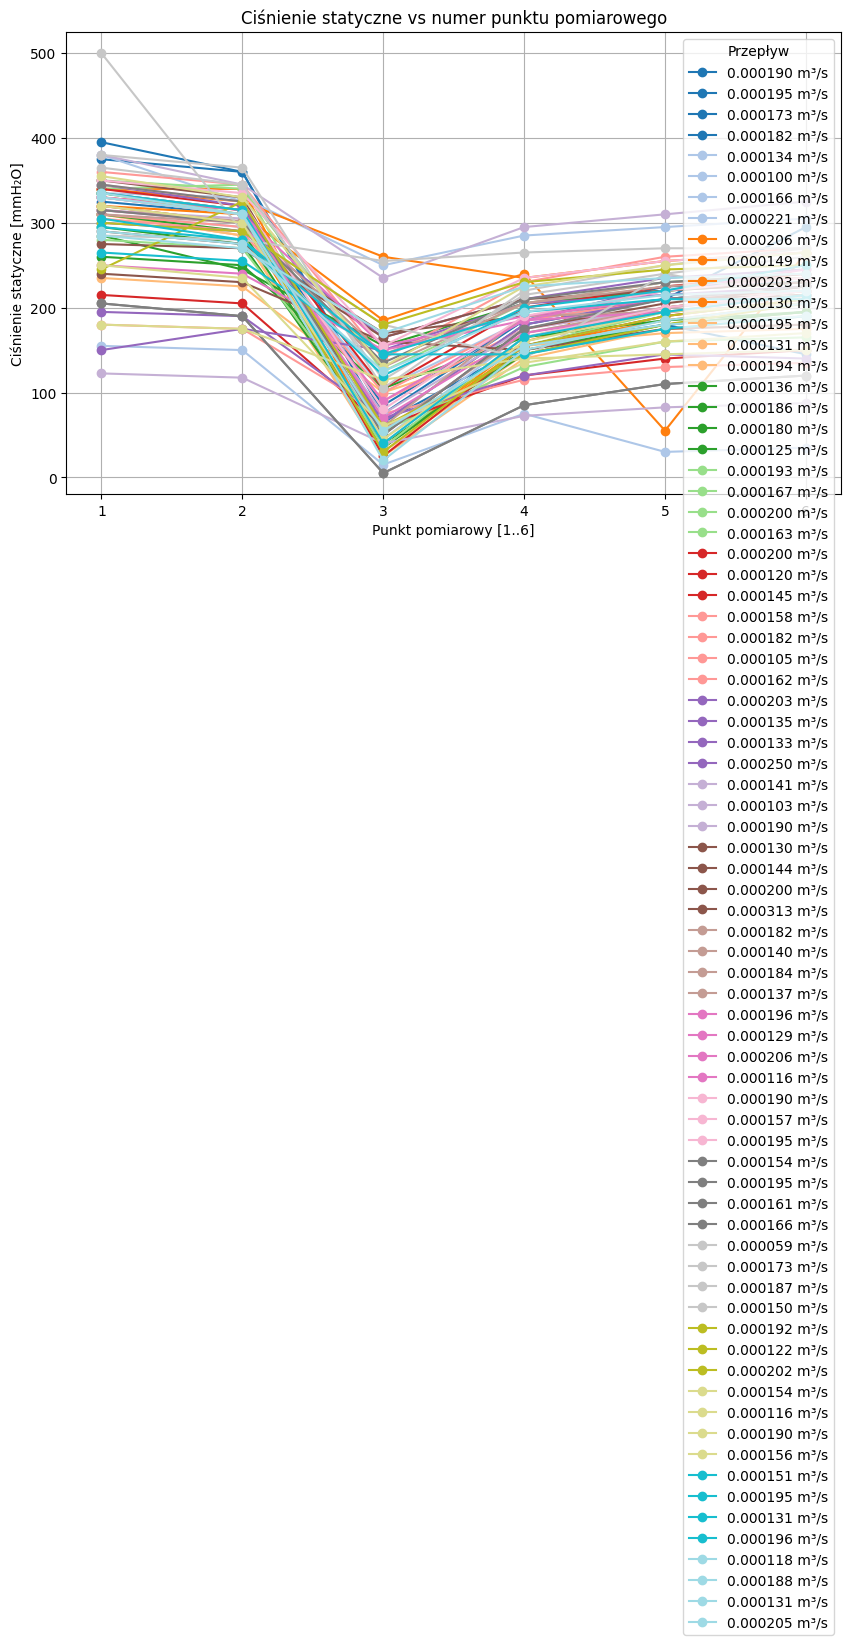

/var/folders/xx/5f2tq_wx78x3tjjqy3rgx2jr0000gp/T/ipykernel_74183/517620295.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


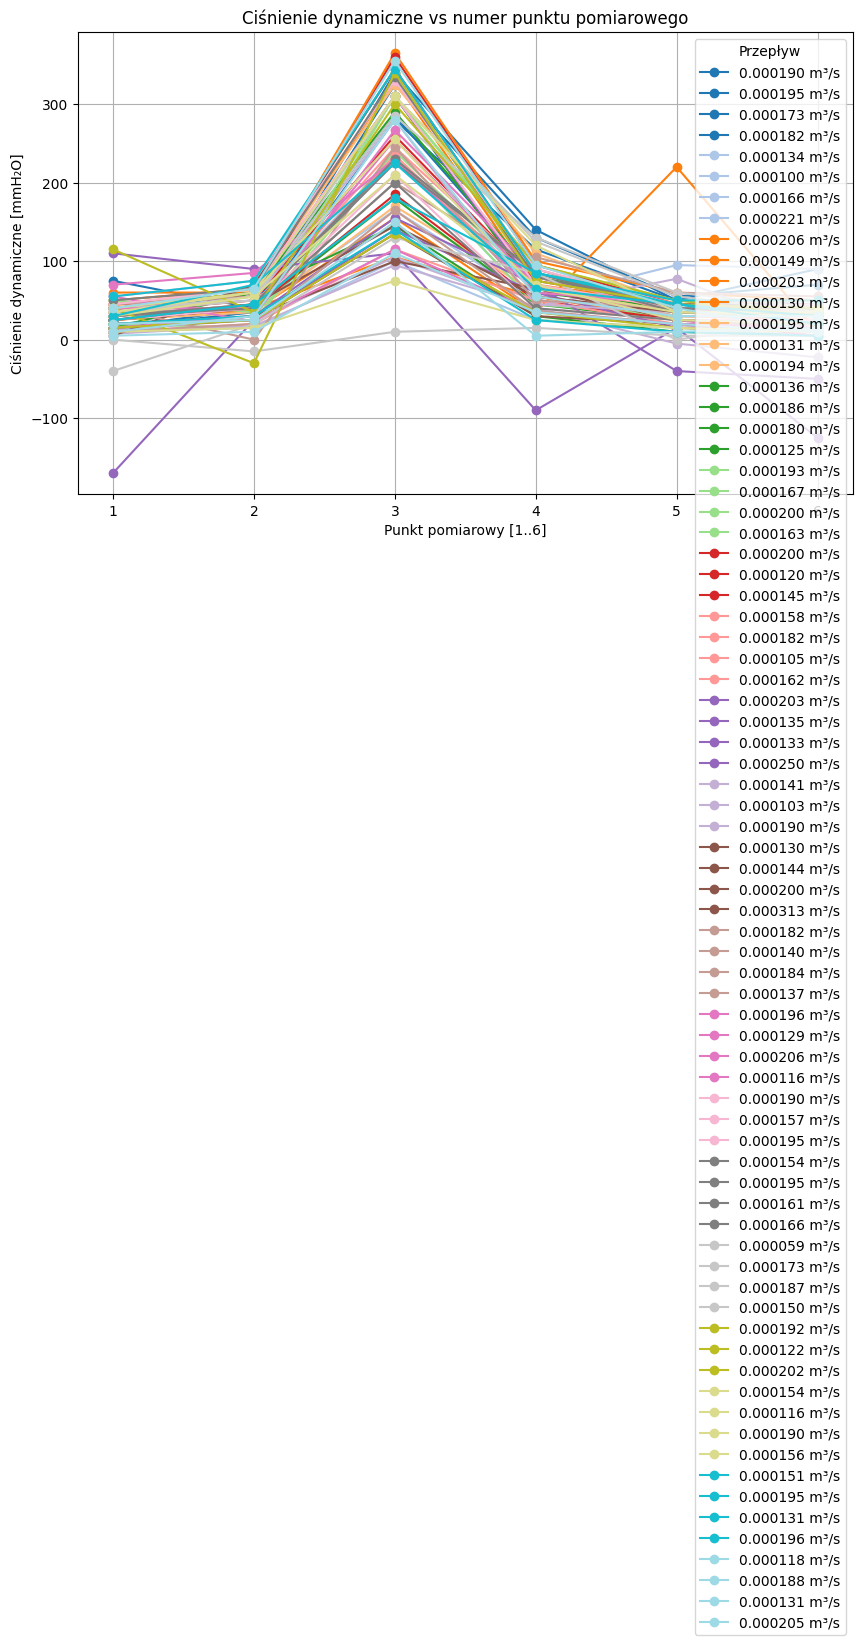

/var/folders/xx/5f2tq_wx78x3tjjqy3rgx2jr0000gp/T/ipykernel_74183/517620295.py:47: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


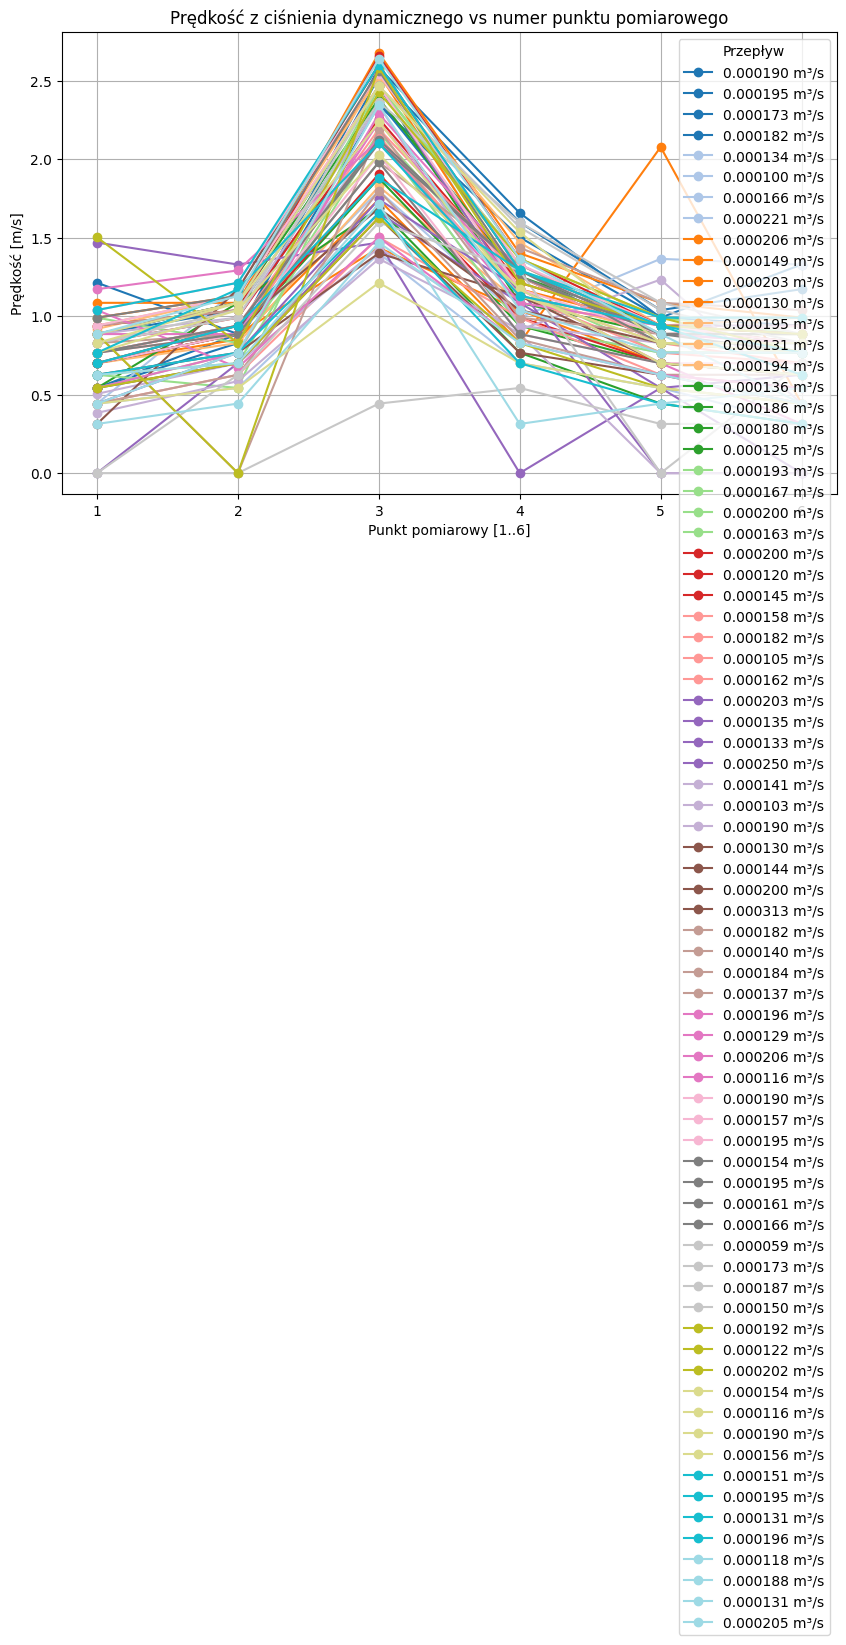

/var/folders/xx/5f2tq_wx78x3tjjqy3rgx2jr0000gp/T/ipykernel_74183/517620295.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


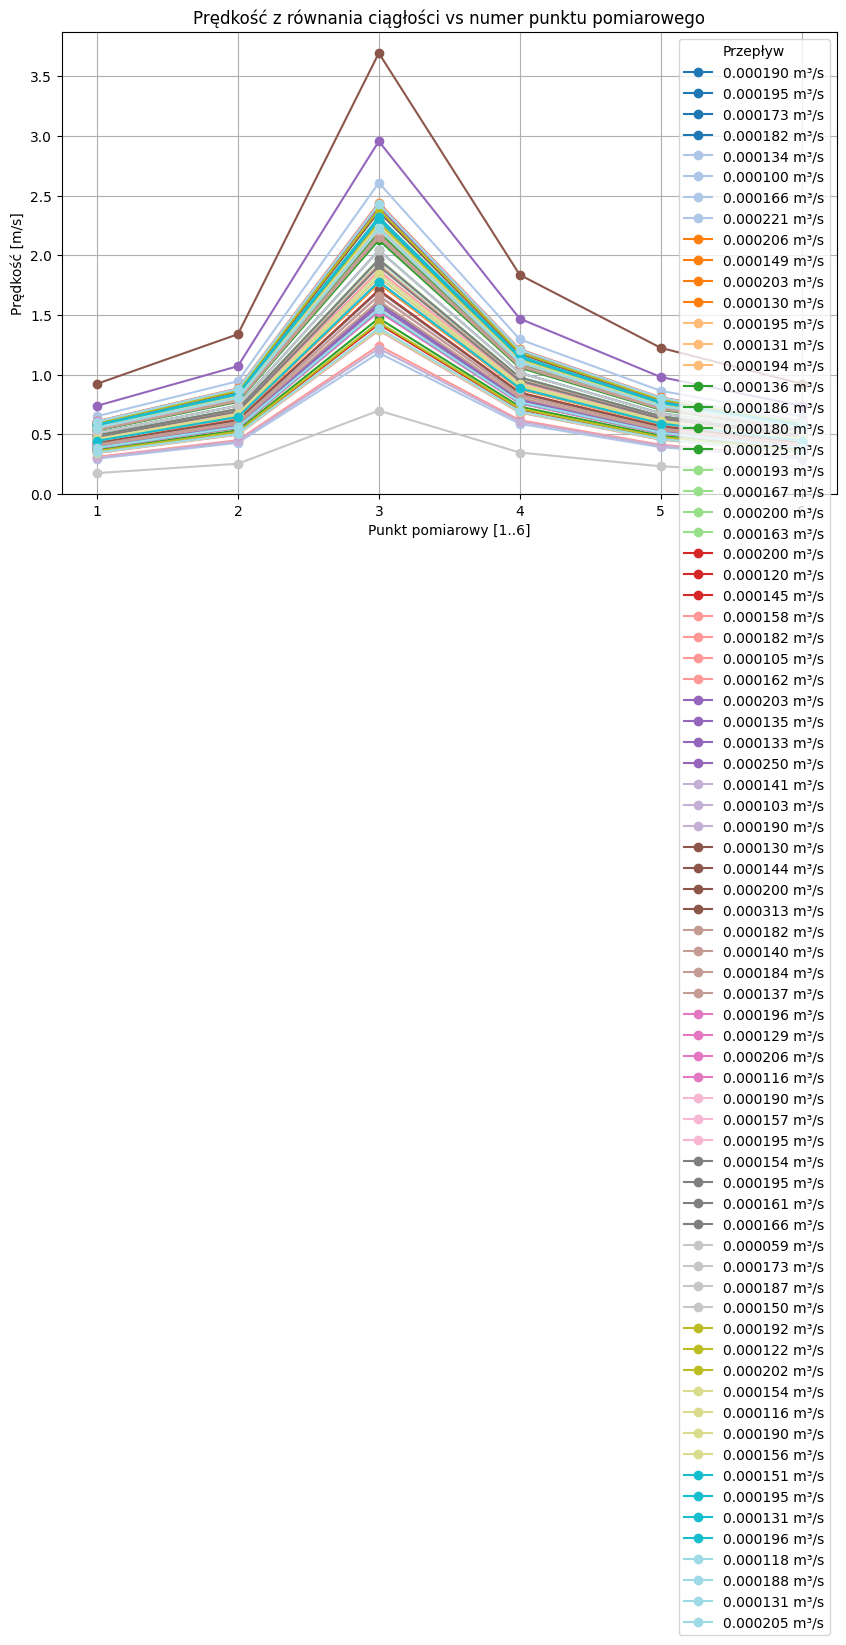

In [12]:


x = np.arange(1, 7)

colors = plt.cm.tab20(np.linspace(0, 1, len(df_wide)))

def flow_label(run):
    q = df_flow.loc[run, ("Natężenie przepływu", "Q, m3/s")]
    return f"{q:.6f} m³/s"

plt.figure(figsize=(10, 6))
for i, (run, row) in enumerate(df_wide.iterrows()):
    static_vals = [row[("Ciśnienie statyczne, mmH2O", str(j))] for j in range(1, 7)]
    plt.plot(x, static_vals, marker="o", color=colors[i], label=flow_label(run))

plt.title("Ciśnienie statyczne vs numer punktu pomiarowego")
plt.xlabel("Punkt pomiarowy [1..6]")
plt.ylabel("Ciśnienie statyczne [mmH₂O]")
plt.grid(True)
plt.legend(title="Przepływ")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for i, (run, row) in enumerate(df_wide.iterrows()):
    static_vals = np.array([row[("Ciśnienie statyczne, mmH2O", str(j))] for j in range(1, 7)])
    total_vals  = np.array([row[("Ciśnienie całkowite, mmH2O", str(j))] for j in range(1, 7)])
    dyn = total_vals - static_vals
    plt.plot(x, dyn, marker="o", color=colors[i], label=flow_label(run))

plt.title("Ciśnienie dynamiczne vs numer punktu pomiarowego")
plt.xlabel("Punkt pomiarowy [1..6]")
plt.ylabel("Ciśnienie dynamiczne [mmH₂O]")
plt.grid(True)
plt.legend(title="Przepływ")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for i, (run, row) in enumerate(df_flow.iterrows()):
    vel_dyn = [row[("Prędkość z ciśnienia dynamicznego, m/s", str(j))] for j in range(1, 7)]
    plt.plot(x, vel_dyn, marker="o", color=colors[i], label=flow_label(run))

plt.title("Prędkość z ciśnienia dynamicznego vs numer punktu pomiarowego")
plt.xlabel("Punkt pomiarowy [1..6]")
plt.ylabel("Prędkość [m/s]")
plt.grid(True)
plt.legend(title="Przepływ")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for i, (run, row) in enumerate(df_flow.iterrows()):
    vel_cont = [row[("Prędkość z równania ciągłości, m/s", str(j))] for j in range(1, 7)]
    plt.plot(x, vel_cont, marker="o", color=colors[i], label=flow_label(run))

plt.title("Prędkość z równania ciągłości vs numer punktu pomiarowego")
plt.xlabel("Punkt pomiarowy [1..6]")
plt.ylabel("Prędkość [m/s]")
plt.grid(True)
plt.legend(title="Przepływ")
plt.tight_layout()
plt.show()



### Model

In [13]:

X = df_flow["Prędkość z ciśnienia dynamicznego, m/s"].values
y = df_flow["Prędkość z równania ciągłości, m/s"].values    
 
print("X shape:", X.shape)
print("y shape:", y.shape)
print()
 
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42
)
 
# normalizacja, w matlabie fitnet robi to automatycznie
 
scaler_X = StandardScaler()
scaler_y = StandardScaler()
 
X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
 
y_train_sc = scaler_y.fit_transform(y_train)
y_val_sc   = scaler_y.transform(y_val)
 
# MLPRegressor z 1 ukrytą warstwą 10 neuronów, funkcja aktywacji 'tanh' (jak w MATLAB fitnet), solver 'lbfgs'
 
net = MLPRegressor(
    hidden_layer_sizes=(10,),
    activation="tanh",
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
    tol=1e-6,
)
 
net.fit(X_train_sc, y_train_sc)
 
y_pred_train_sc = net.predict(X_train_sc)
y_pred_val_sc   = net.predict(X_val_sc)
 
y_pred_train = scaler_y.inverse_transform(y_pred_train_sc)
y_pred_val   = scaler_y.inverse_transform(y_pred_val_sc)
 
y_pred_all_sc = net.predict(scaler_X.transform(X))
y_pred_all    = scaler_y.inverse_transform(y_pred_all_sc)
 
# Wydajność (MSE — to samo co MATLABowe perform())
 
mse_train = mean_squared_error(y_train, y_pred_train)
mse_val   = mean_squared_error(y_val,   y_pred_val)
mse_all   = mean_squared_error(y,       y_pred_all)
r2_all    = r2_score(y, y_pred_all)
 
print(f"performance (MSE, full dataset) = {mse_all:.6f}")
print(f"MSE train  = {mse_train:.6f}")
print(f"MSE val    = {mse_val:.6f}")
print(f"R²  (all)  = {r2_all:.4f}")
print()
 
# Wykresy — replika MATLABowych plotperform, ploterrhist, plotregression
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Bernoulli NN — scikit-learn replication of MATLAB fitnet", fontsize=13)
 
ax = axes[0]
from sklearn.neural_network import MLPRegressor as _MLP
_net_adam = _MLP(hidden_layer_sizes=(10,), activation="tanh", solver="adam",
                 max_iter=500, random_state=42, tol=1e-8)
_net_adam.fit(X_train_sc, y_train_sc)
ax.semilogy(_net_adam.loss_curve_, color="royalblue", linewidth=1.5)
ax.set_title("Training Performance")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled)")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
 
ax = axes[1]
errors = (y - y_pred_all).ravel()
ax.hist(errors, bins=15, color="steelblue", edgecolor="white", linewidth=0.6)
ax.axvline(0, color="red", linewidth=1.5, linestyle="--", label="Zero error")
ax.set_title("Error Histogram")
ax.set_xlabel("Error (m/s)")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
 
ax = axes[2]
t_flat = y.ravel()
y_flat = y_pred_all.ravel()
 
m, b = np.polyfit(t_flat, y_flat, 1)
x_line = np.linspace(t_flat.min(), t_flat.max(), 200)
 
ax.scatter(t_flat, y_flat, color="royalblue", alpha=0.7, s=25, label="Data")
ax.plot(x_line, m * x_line + b, color="red",   linewidth=1.5, label=f"Fit  Y={m:.3f}T+{b:.4f}")
ax.plot(x_line, x_line,         color="black",  linewidth=1,   linestyle="--", label="Y = T")
ax.set_title(f"Regression  (R = {np.sqrt(r2_all):.4f})")
ax.set_xlabel("Target (continuity, m/s)")
ax.set_ylabel("Output (predicted, m/s)")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)
 
plt.tight_layout()
plt.show()
 

X shape: (75, 6)
y shape: (75, 6)



ValueError: Input X contains NaN.
MLPRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values